In [1]:
import os
import inspect
import seaborn
import matplotlib
import matplotlib.pyplot as plt
import torch
import scanpy as sc
import pyro

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

torch.set_float32_matmul_precision('high')

import sys
sys.path.append('/home/matthew.schmitz/Matthew/code/scANTIPODE/')
import antipode
from antipode.antipode_model import *
import antipode.model_functions
from antipode.model_functions import *
import antipode.model_distributions
from antipode.model_distributions import *
import antipode.model_modules
from antipode.model_modules import *
import antipode.train_utils
from antipode.train_utils import *
import antipode.plotting
from antipode.plotting import *



/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is available
Number of GPUs: 1
GPU Name: NVIDIA A100-PCIE-40GB


In [2]:
model_tag='LGN-SCVI'
adata=sc.read_h5ad(os.path.expanduser('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/data/LGN/hqrm_lgn.h5ad'),backed='r')
adata=adata[adata.obs['species']!='mouse',:].to_memory()
adata.uns['species_colors']=['teal','pink','goldenrod','forestgreen']
batch_key='batch'
discov_key='species'
layer_key='UMIs'

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
num_var=adata.shape[1]
batch_size=32
level_sizes=[1,10,50]
num_latent=200
steps=0
max_steps=100000
print_every=5000


In [4]:
scvi.model.SCVI.setup_anndata(adata, layer=layer_key, batch_key=batch_key,categorical_covariate_keys=[discov_key])#'roi',,
scvi_model = scvi.model.SCVI (adata, n_latent=num_latent,n_layers=3,n_hidden=2048)
scvi_model.train(100)
SCVI_LATENT_KEY = "X_SCVI"
adata.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation(adata)
scvi_model.save(os.path.join('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/models/',model_tag),overwrite=True) 

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/util

Epoch 50/50: 100%|██████████| 50/50 [04:19<00:00,  5.09s/it, v_num=1, train_loss_step=1.22e+4, train_loss_epoch=1.36e+4]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [04:19<00:00,  5.19s/it, v_num=1, train_loss_step=1.22e+4, train_loss_epoch=1.36e+4]


INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


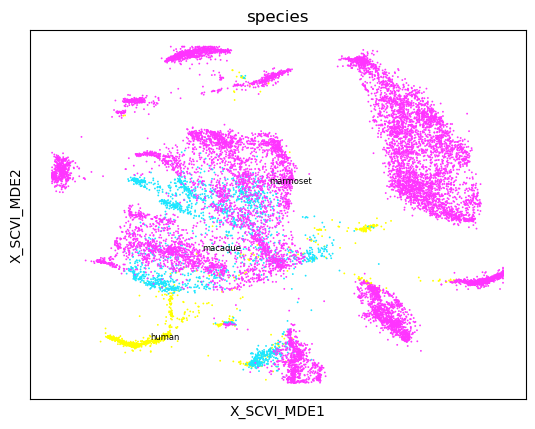

In [5]:
MDE_KEY = "X_SCVI_MDE"
adata.obsm[MDE_KEY] = clip_latent_dimensions(scvi.model.utils.mde(adata.obsm['X_SCVI'],init='random'),0.1)
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["species"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

In [6]:

# Clear Pyro param store so we don't conflict with previous run
try:
    pyro.clear_param_store()
    del antipode_model
    torch.cuda.empty_cache()
except:
    pass
# Fix random number seed to a lucky number
pyro.util.set_rng_seed(13)
# Enable optional validation warnings
pyro.enable_validation(False)

# Instantiate instance of model/guide and various neural networks
antipode_model = ANTIPODE(num_latent=num_latent,level_sizes=level_sizes,bi_depth=2,num_batch_embed=10,psi_levels=[0.,1.,1.],
                adata=adata,discov_pair=('obs',discov_key),batch_pair=('obs',batch_key),layer=layer_key,
                use_psi=True,use_q_score=True,prior_scale=50.,sampler_category='species',dist_normalize=False,
                scale_init_val=0.01,loc_as_param=False,zdw_as_param=False,intercept_as_param=False)


# Training Phase 2: Intializing layered tree

In [7]:
adata.obsm['X_SCVI'] = (adata.obsm['X_SCVI'] - np.mean(adata.obsm['X_SCVI'])) / np.std(adata.obsm['X_SCVI'])

In [ ]:
antipode_model.prepare_phase_2(epochs=2,device=device,dimension_reduction='X_SCVI')

In [9]:
antipode_model.train_phase(phase=2,max_steps=int(max_steps/2),print_every=10000,num_particles=3,device=device, max_learning_rate=5e-4, one_cycle_lr=True, batch_size=32,freeze_encoder=False)

  4%|▍         | 2000/50000 [07:07<2:32:46,  5.24it/s]

fix scale factor


  6%|▌         | 3035/50000 [09:58<2:20:00,  5.59it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

 40%|████      | 20002/50000 [56:24<1:06:49,  7.48it/s]

[Step 20000]  Loss: 0.06437


 44%|████▍     | 21937/50000 [1:01:12<1:29:21,  5.23it/s]

KeyboardInterrupt: 

In [10]:
!nvidia-smi
antipode_model.to('cpu')
torch.cuda.empty_cache()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


|    0   N/A  N/A    109664      C   ...forge3/envs/antipode/bin/python3.11     3662MiB |
|    0   N/A  N/A    116725      C   ...forge3/envs/antipode/bin/python3.11     5564MiB |
+---------------------------------------------------------------------------------------+
^C
Wed May 22 10:27:17 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:64:00.0 Off 

In [11]:
antipode_model.store_outputs(device=device,prefix='')

In [12]:
!nvidia-smi
antipode_model.to('cpu')
torch.cuda.empty_cache()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Wed May 22 10:27:25 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:64:00.0 Off |                    0 |
| N/A   37C    P0             124W / 250W |   7537MiB / 40960MiB |     35%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

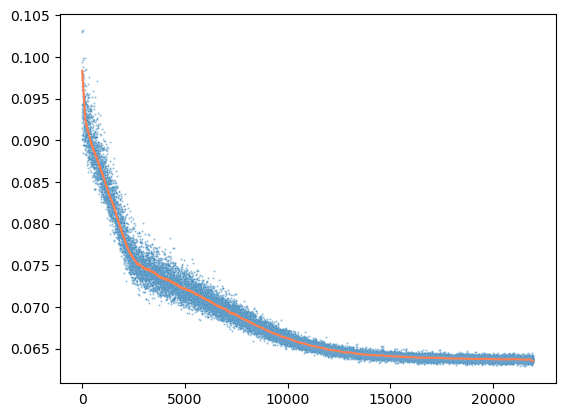

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


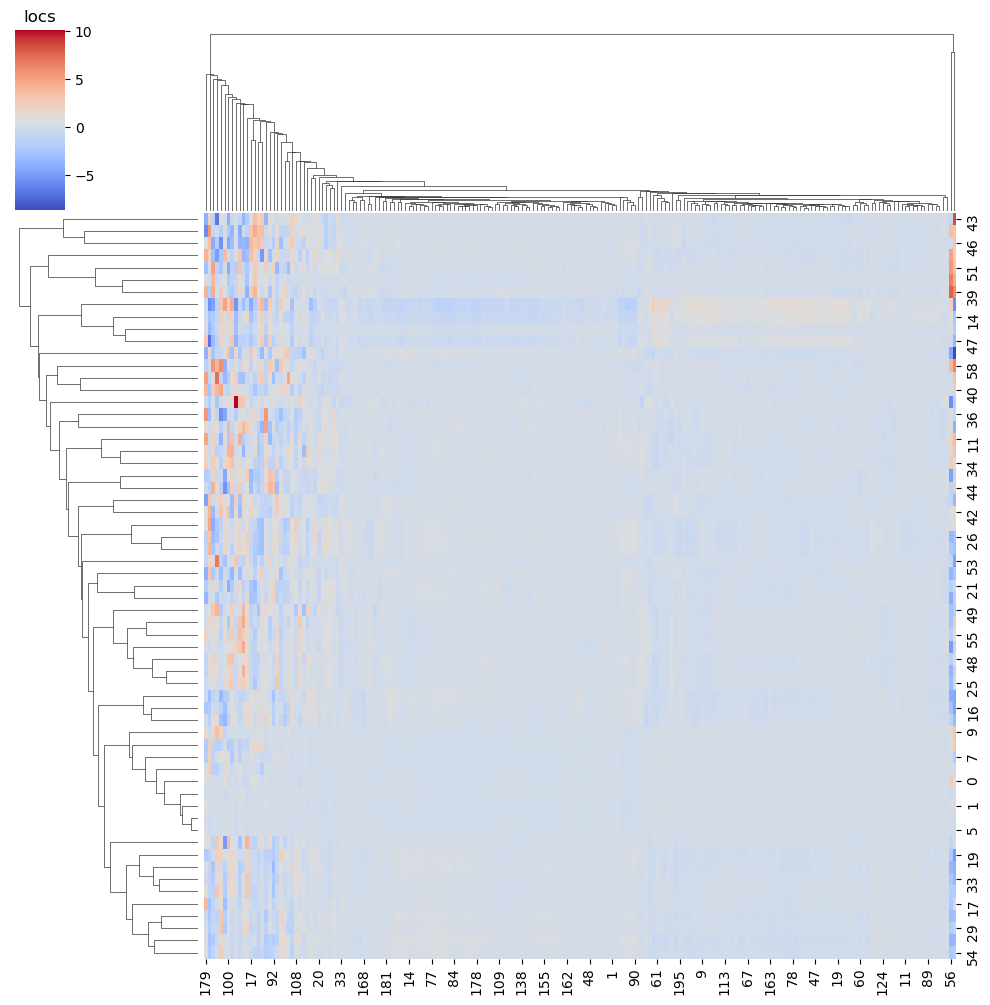

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


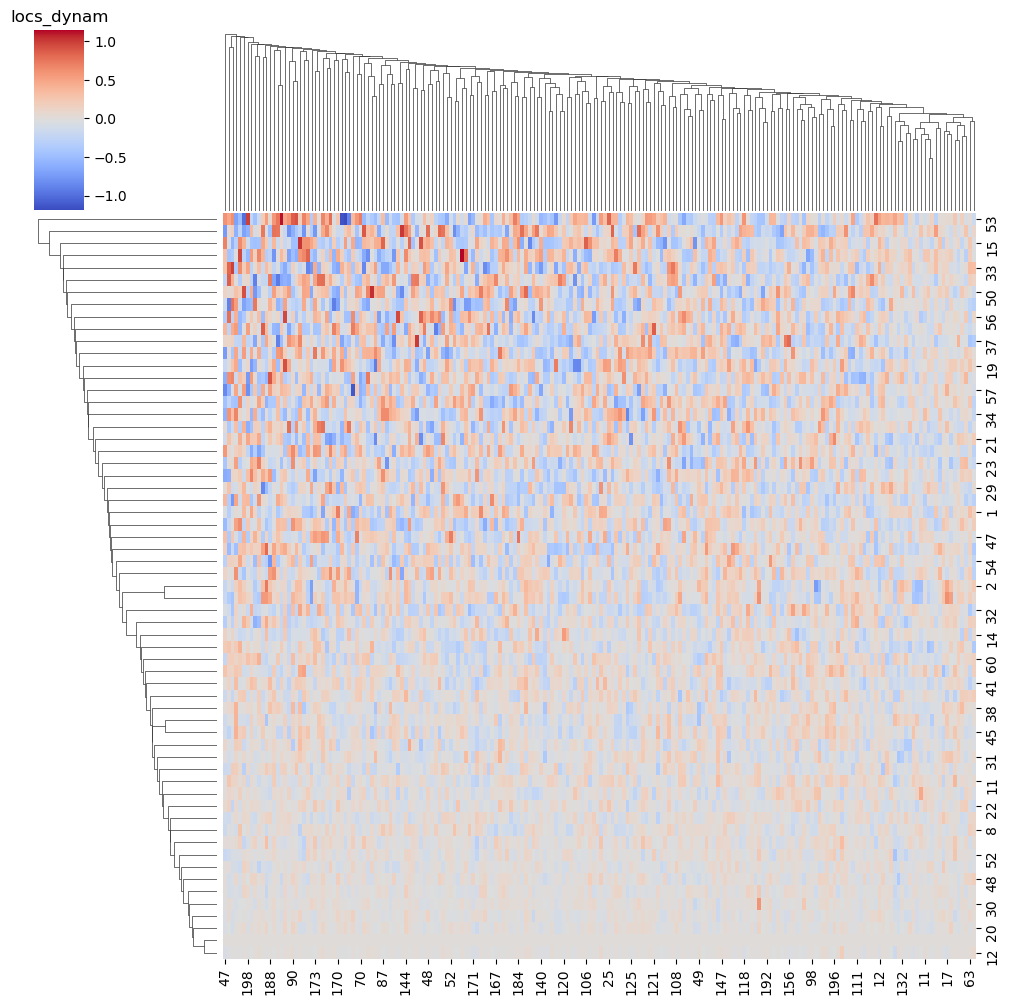

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


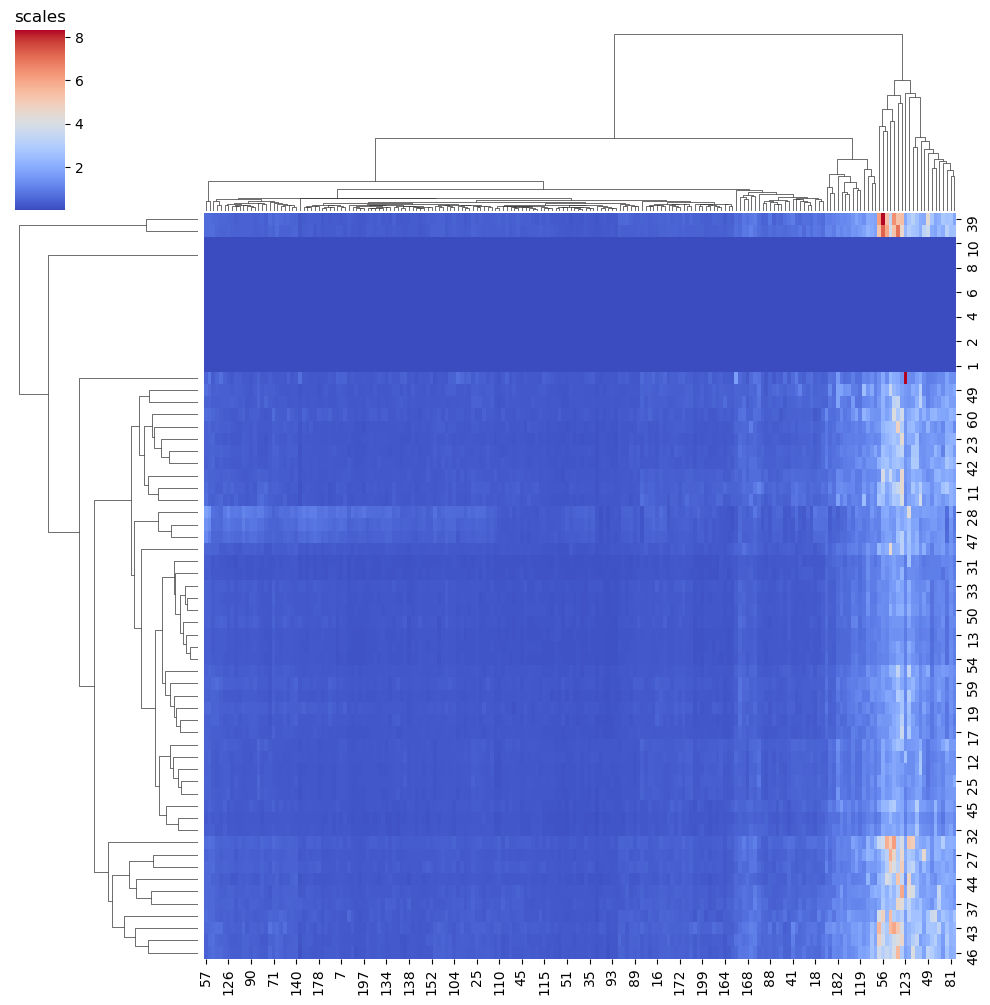

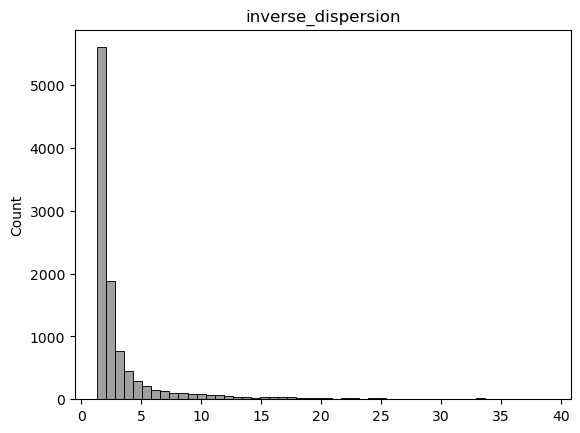

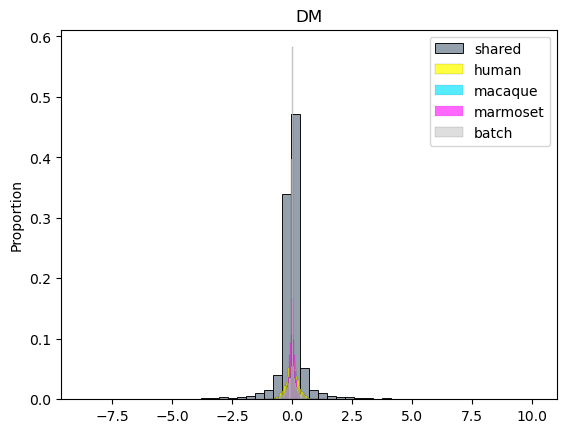

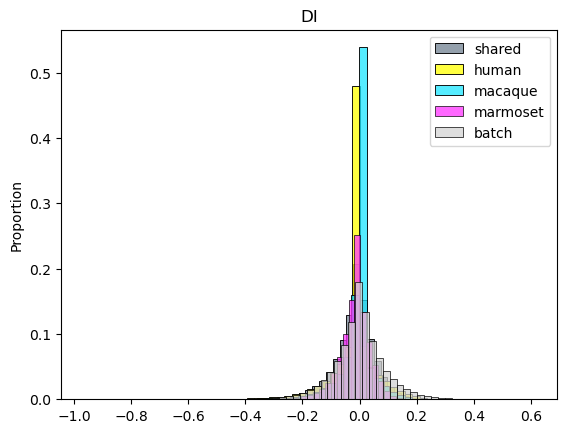

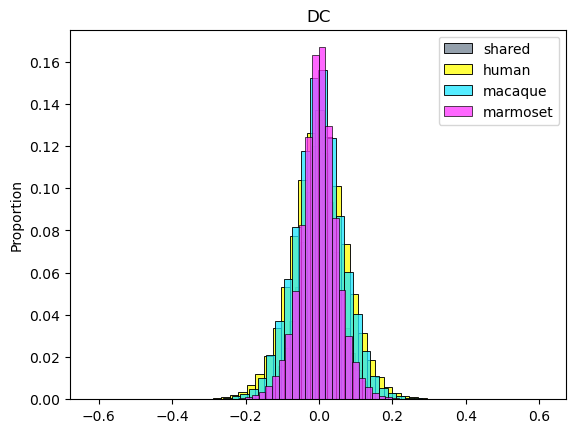

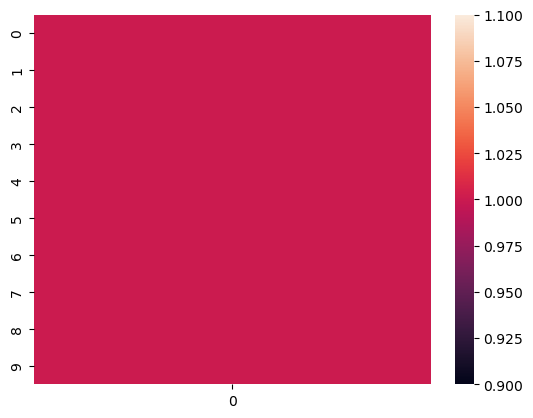

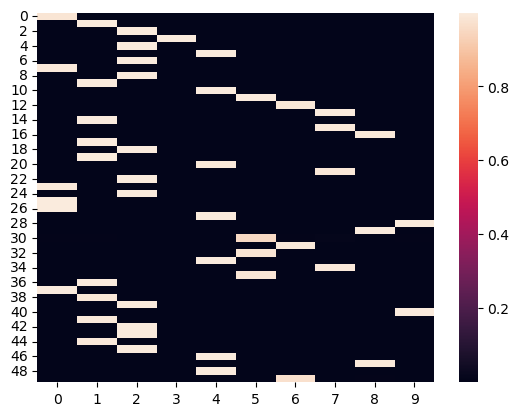

In [13]:
plot_loss(antipode_model.losses)
plot_gmm_heatmaps(antipode_model)
plot_d_hists(antipode_model)
plot_tree_edge_weights(antipode_model)

In [14]:
antipode_model.save(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),save_anndata=False,prefix='p2_')

# Training Phase 3: Refining the final tree

In [16]:
antipode_model.train_phase(phase=3,max_steps=max_steps,print_every=10000,num_particles=1,device=device, max_learning_rate=1e-3, one_cycle_lr=True, steps=0, batch_size=32)

  0%|          | 1/100000 [00:00<5:14:18,  5.30it/s]

fix scale factor


/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/train_utils.py:282: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if sum(index.shape) == 1:
/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/train_utils.py:285: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  index=torch.nn.functional.one_hot(index.squeeze(),num_classes=out_shape[1]).float() if index.shape[-1]==1 else index
/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/a

fix scale factor


  2%|▏         | 2159/100000 [03:47<2:22:57, 11.41it/s]

...

 10%|█         | 10005/100000 [13:56<1:15:58, 19.74it/s]]

[Step 10000]  Loss: 0.09958


 11%|█         | 10946/100000 [14:43<1:11:00, 20.90it/s]

STEP SKIPPED


 12%|█▏        | 12498/100000 [16:16<1:14:13, 19.65it/s]
KeyboardInterrupt



In [17]:
!nvidia-smi
antipode_model.to('cpu')
torch.cuda.empty_cache()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Wed May 22 11:03:30 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:64:00.0 Off |                    0 |
| N/A   36C    P0              37W / 250W |   7537MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

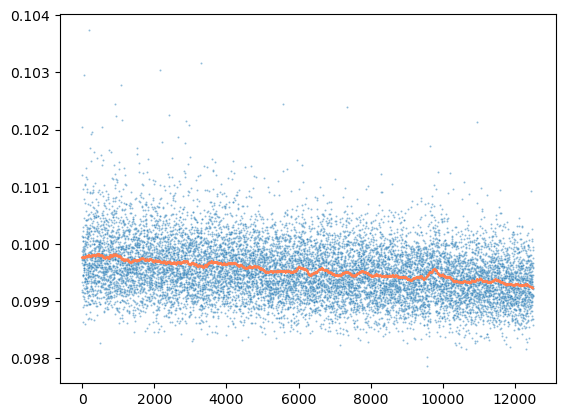

In [18]:
plot_loss(antipode_model.losses)

In [19]:
antipode_model.store_outputs(device=device,prefix='')

In [20]:
!nvidia-smi
antipode_model.to('cpu')
torch.cuda.empty_cache()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Wed May 22 11:03:35 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:64:00.0 Off |                    0 |
| N/A   35C    P0              37W / 250W |   6157MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


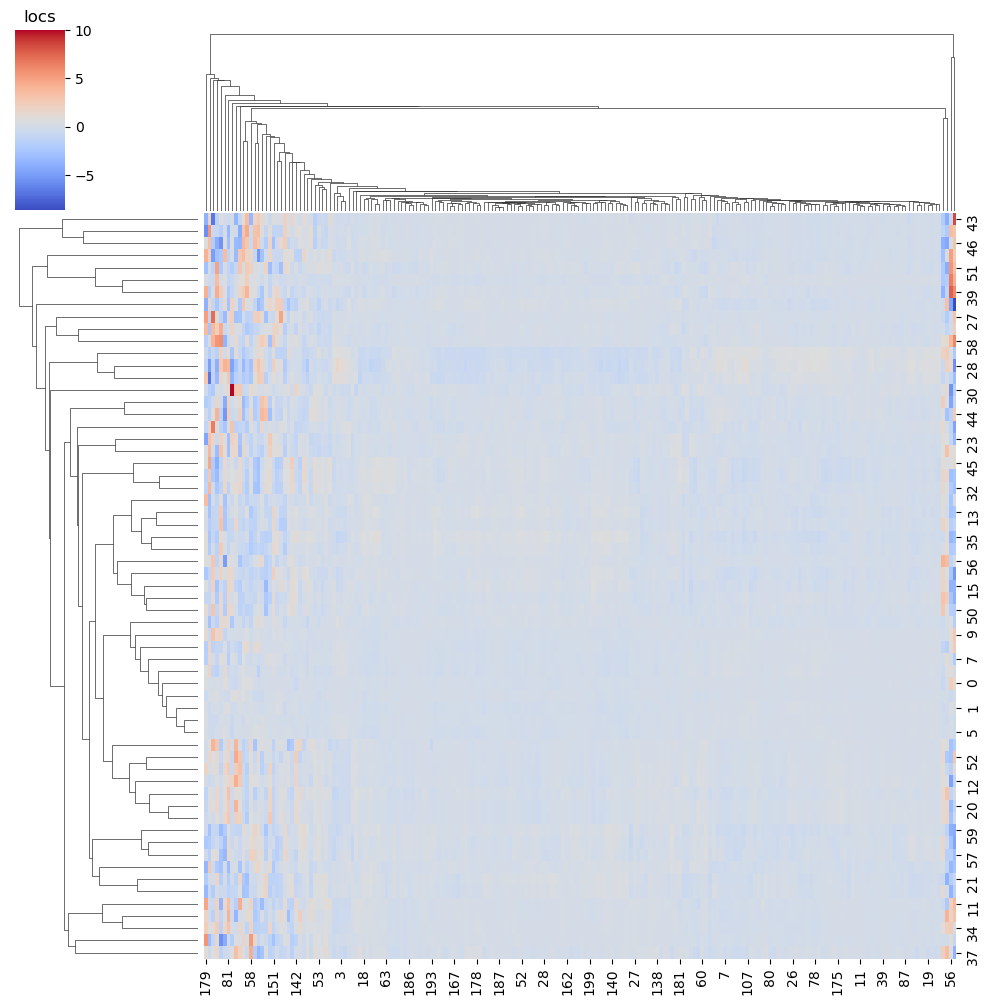

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


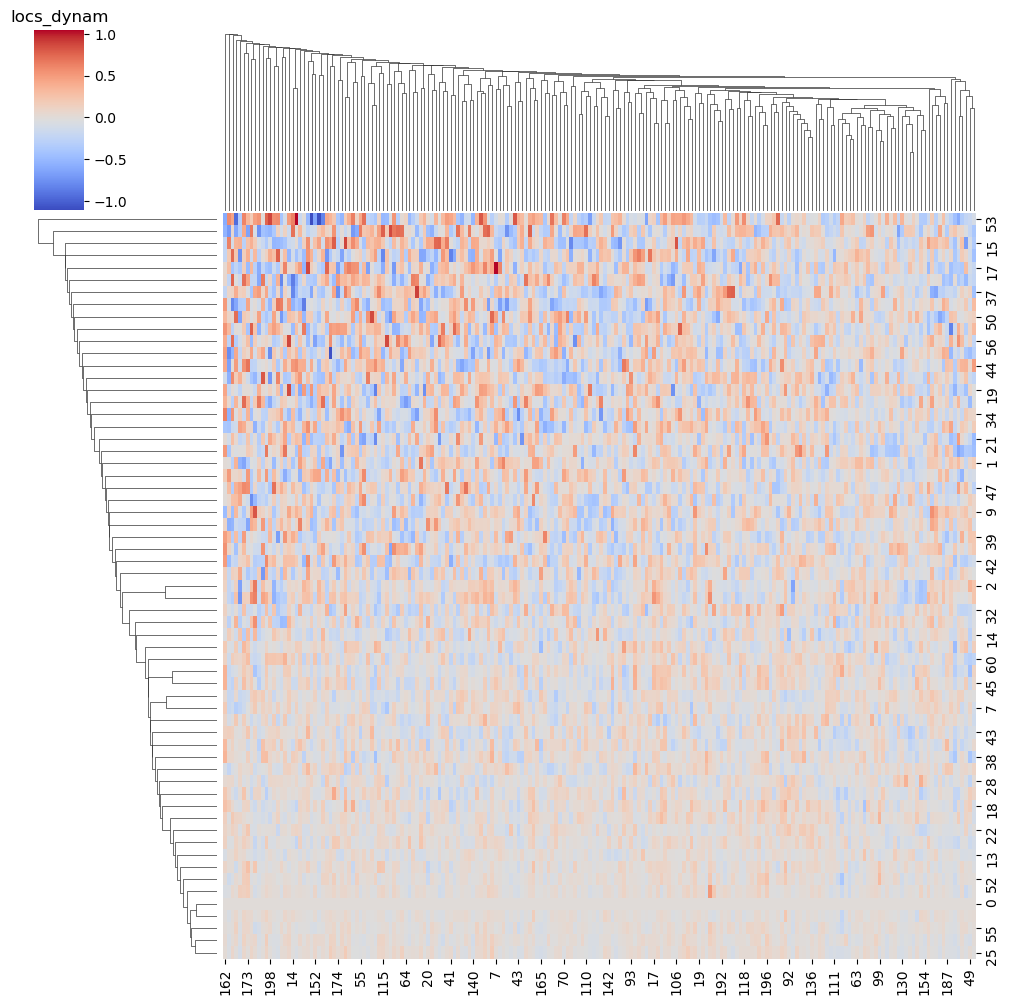

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


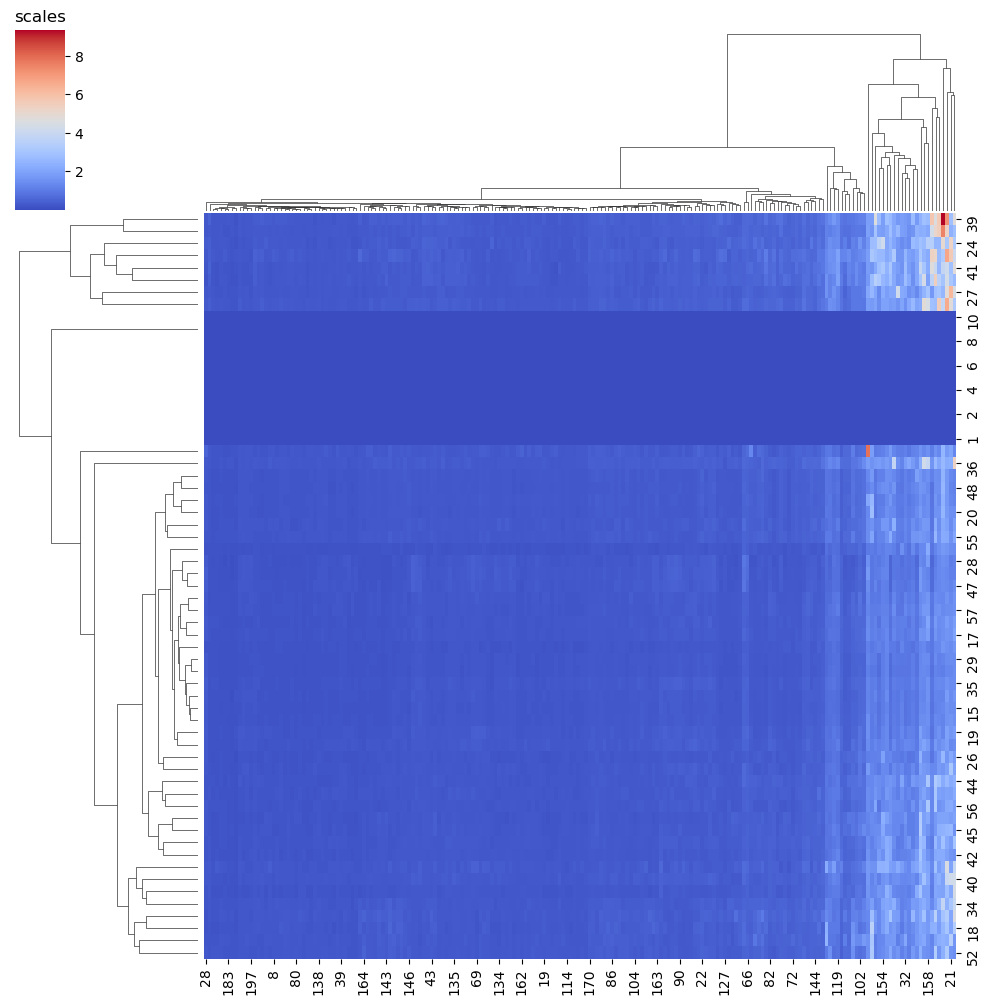

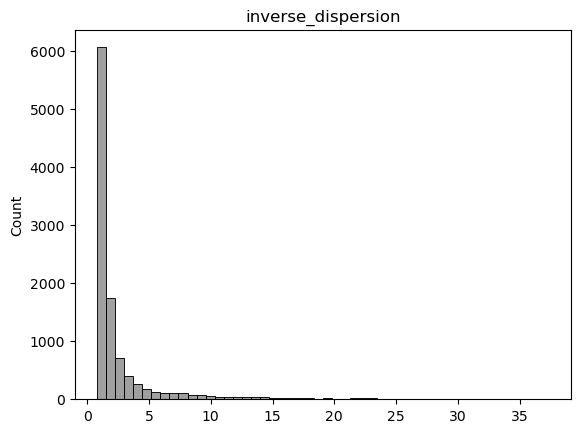

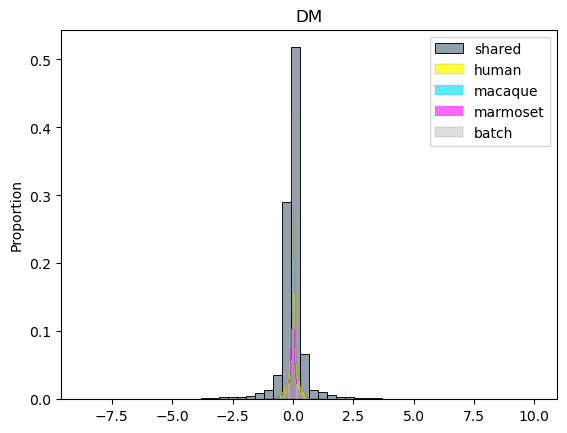

  3%|▎         | 3187/100000 [35:37<18:02:15,  1.49it/s]


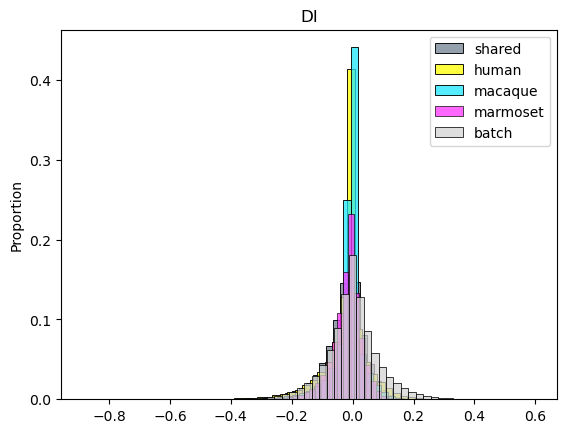

 12%|█▏        | 12499/100000 [16:33<1:14:13, 19.65it/s]

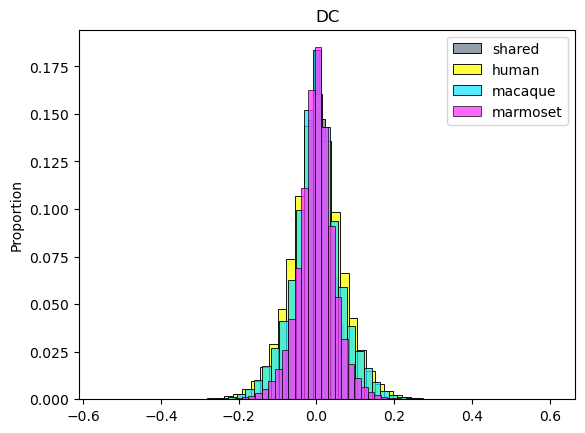

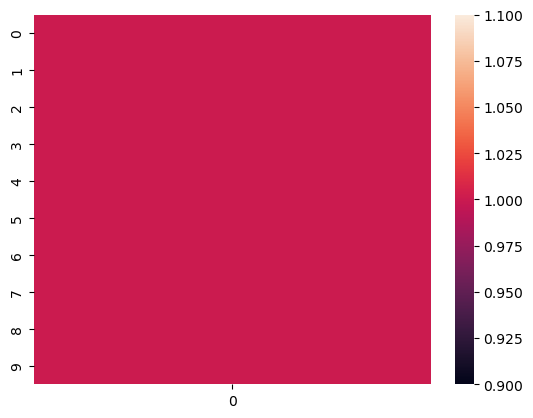

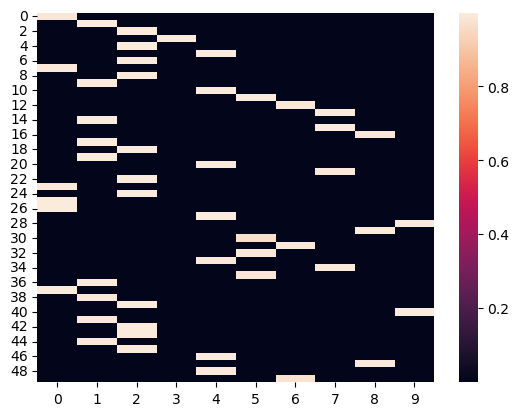

In [21]:
plot_gmm_heatmaps(antipode_model)
plot_d_hists(antipode_model)
plot_tree_edge_weights(antipode_model)

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


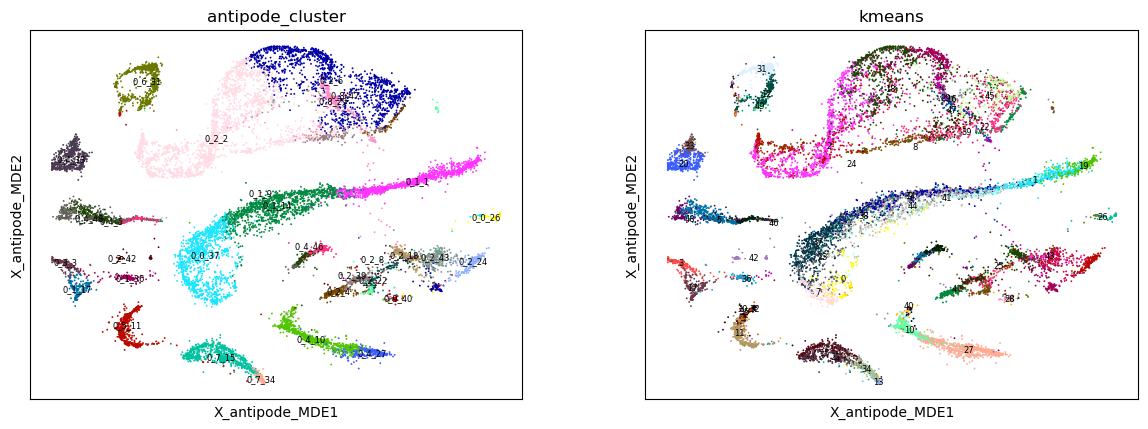

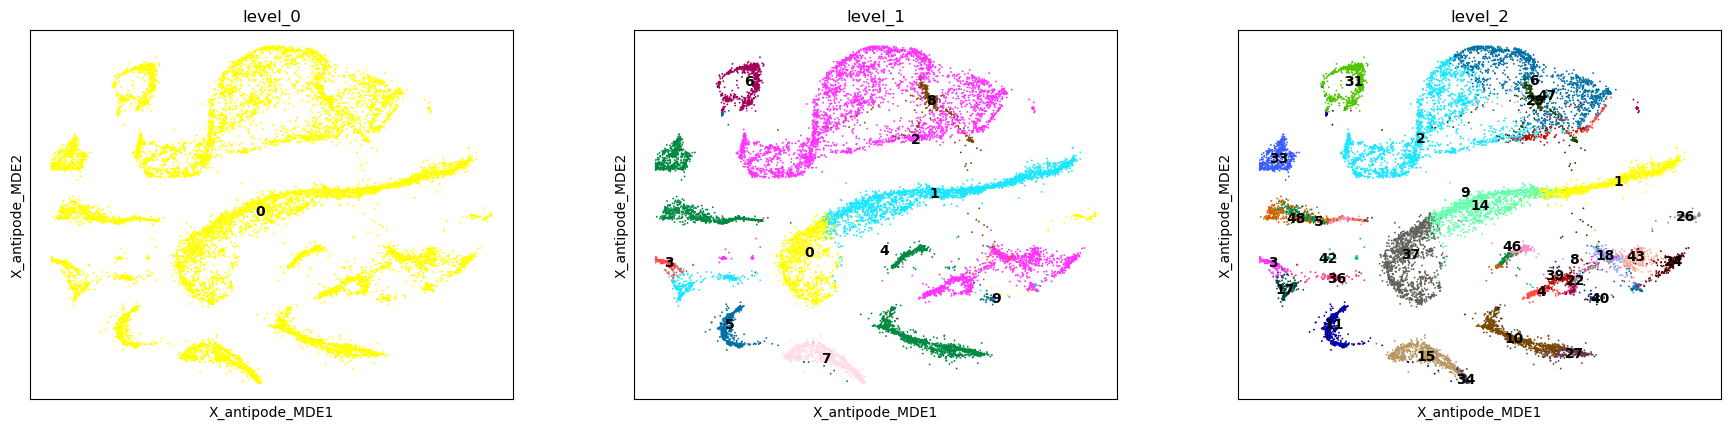

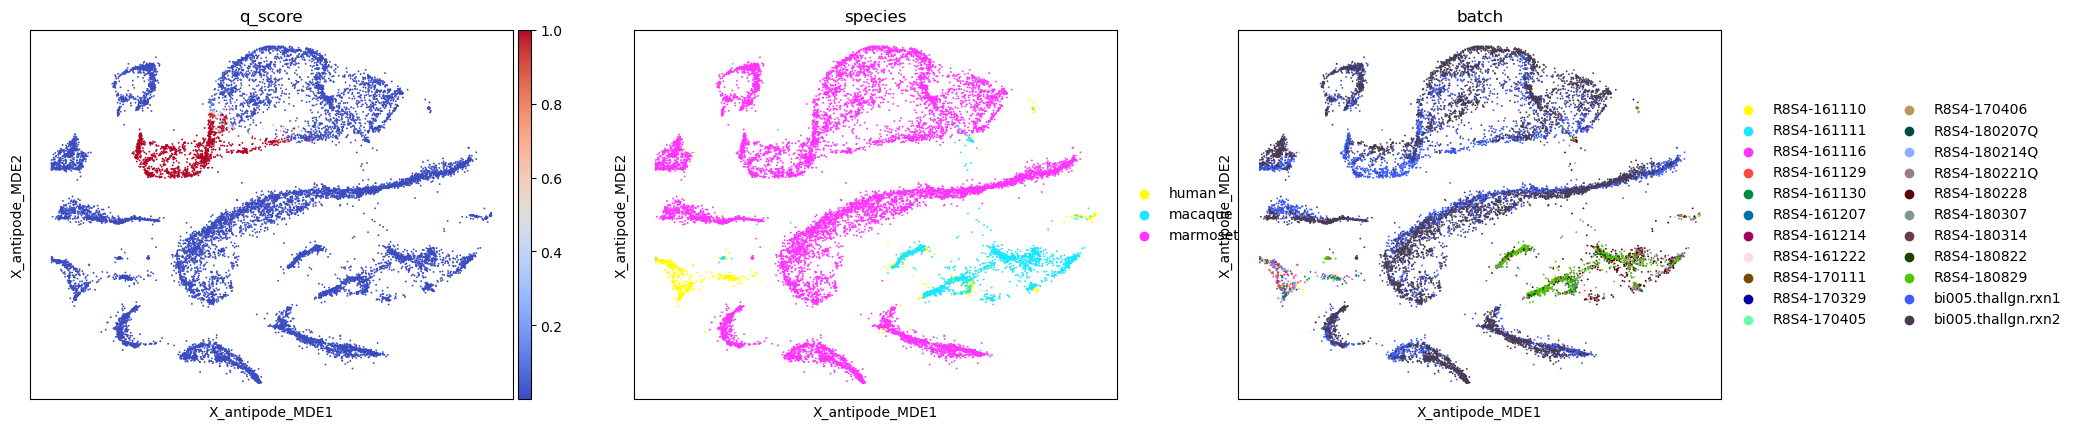

In [23]:
MDE_KEY = "X_antipode_MDE"
adata.obsm[MDE_KEY] = clip_latent_dimensions(scvi.model.utils.mde(adata.obsm['X_antipode'],init='random'),0.1)
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster","kmeans"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'level' in x],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)


In [ ]:
antipode_model.save(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),save_anndata=True,prefix='p3_')

In [ ]:
seaborn.histplot(adata.obs['q_score'])

In [ ]:
random_choice=np.random.choice(adata.obs.index,size=100000,replace=False)
random_choice=np.where(adata.obs.index.isin(random_choice))[0]
xdata=adata[random_choice,:]
xdata=xdata.to_memory().copy()

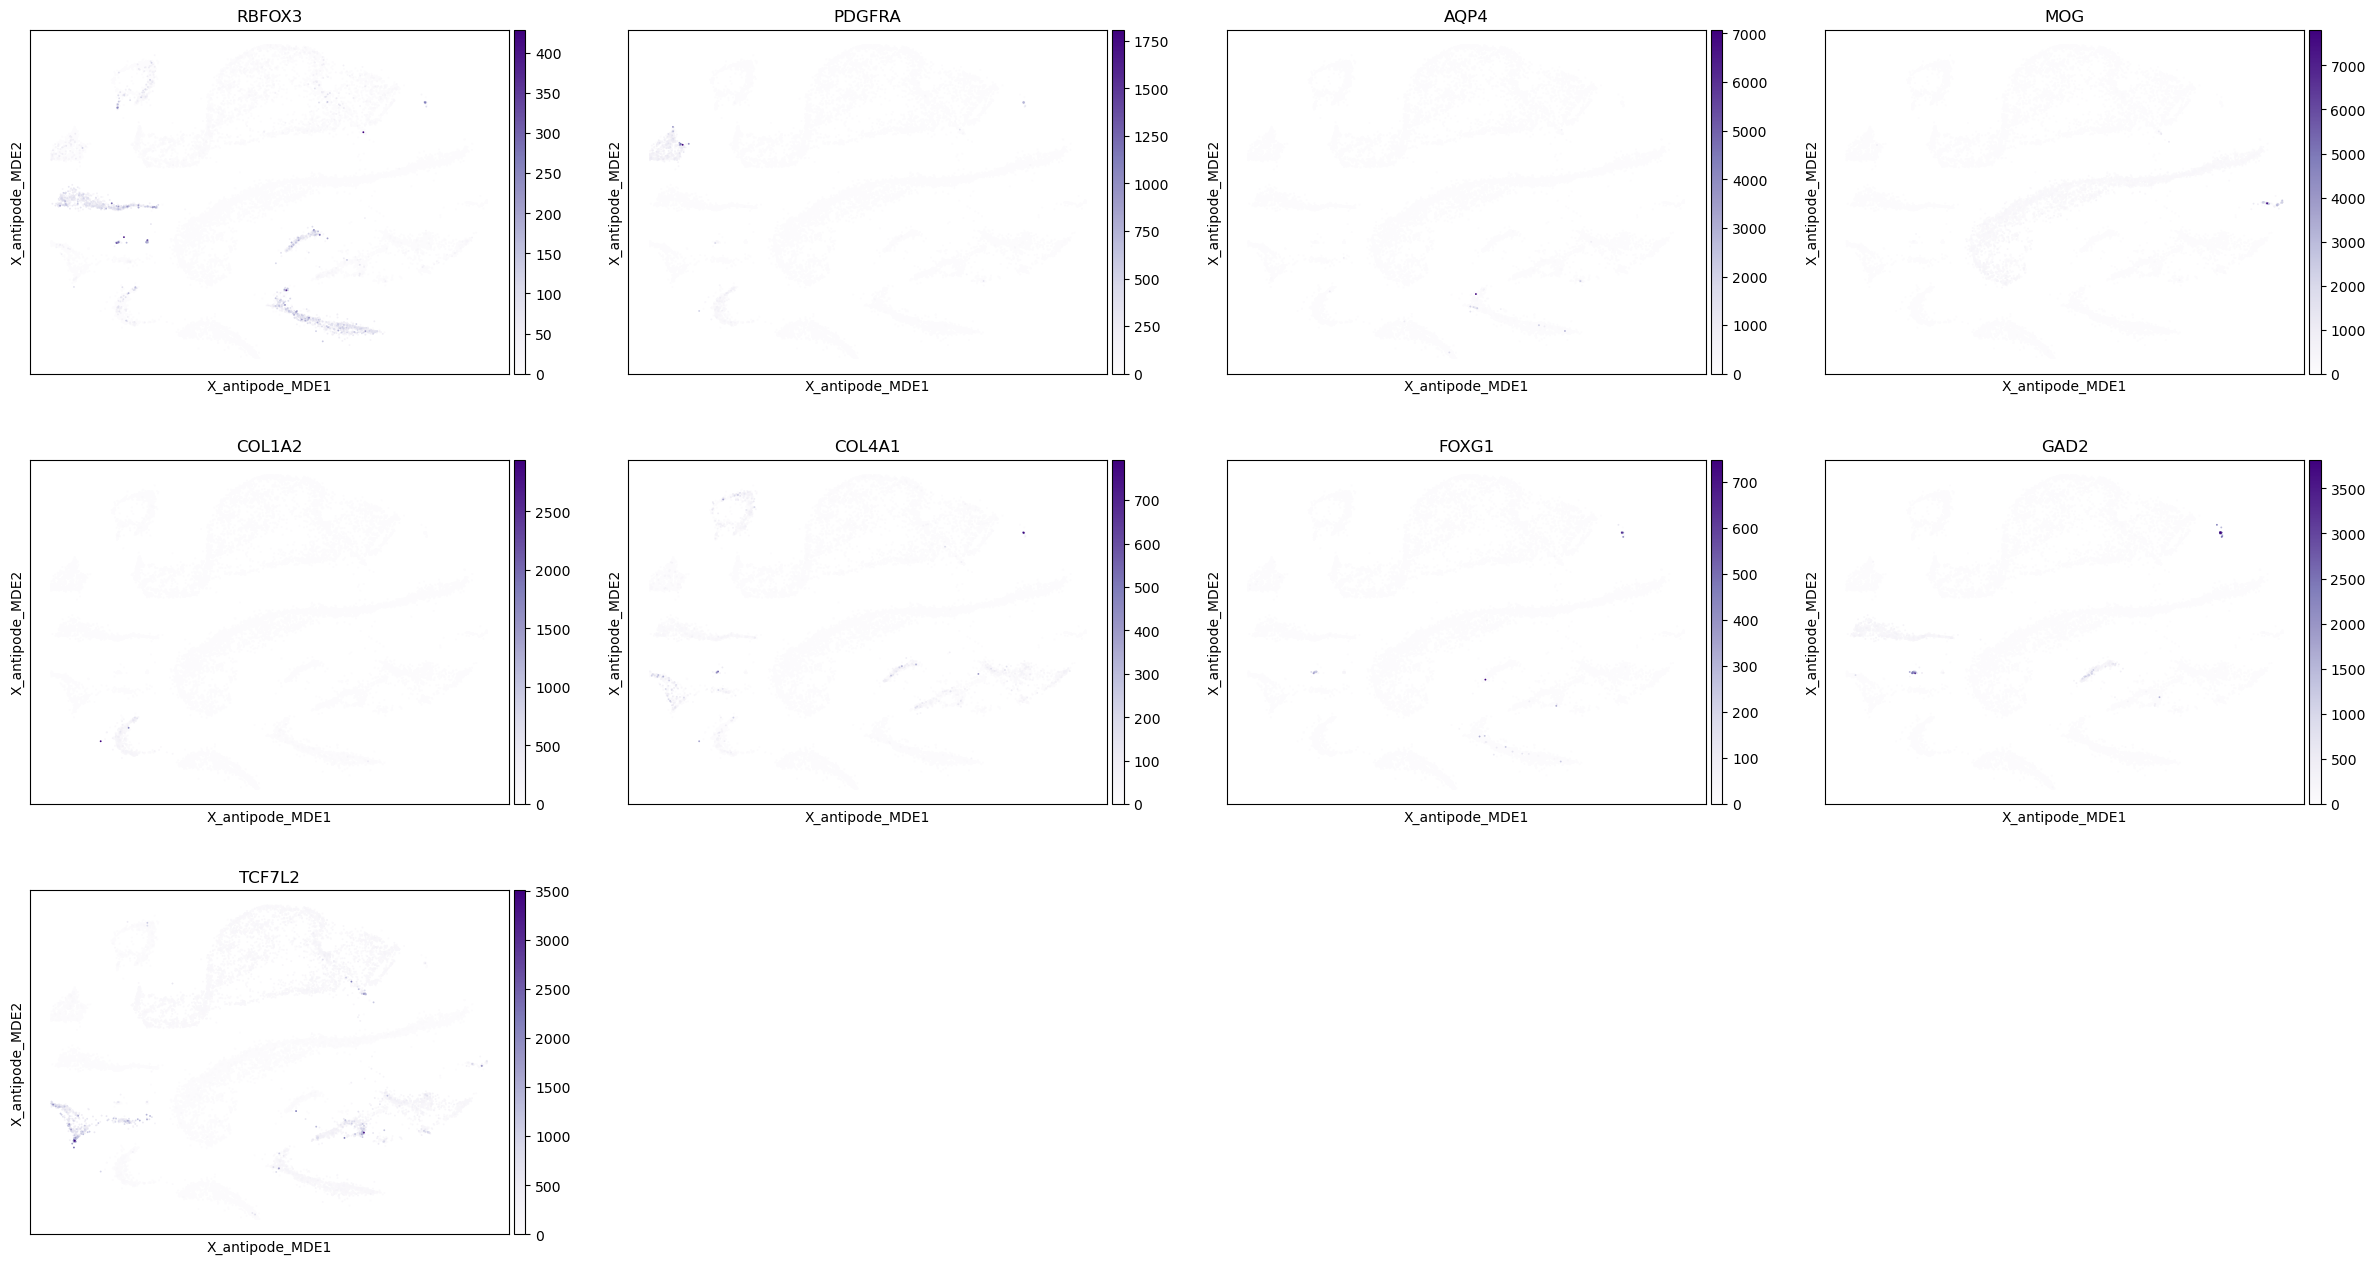

In [24]:
gene_list=['RBFOX3','PDGFRA','AQP4','FOXJ1','AIF1','MOG','COL1A2','CD34','COL4A1','FOXG1','SLC17A6','GAD2','TCF7L2']
gene_list=[x for x in gene_list if x in adata.var.index]
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=gene_list,cmap='Purples',
    palette=sc.pl.palettes.godsnot_102,legend_fontsize=6,
    legend_loc='on data',use_raw=False
)


In [29]:
def melt_param_3d(X,discov_labels,cluster_labels,var_labels):
    dfs=[]
    for i in range(len(discov_labels)):
        for j in range(len(cluster_labels)):
            df=pd.DataFrame(X[i,j,:],columns=['value'])
            df['discov']=discov_labels[i]
            df['cluster']=cluster_labels[j]
            df['var']=var_labels
            dfs.append(df)
    return(pd.concat(dfs,axis=0))

In [26]:
adata.layers['norm_spliced']=adata.layers['UMIs'].copy()
adata.layers['norm_spliced']=scipy.sparse.csr_matrix(1e4*(adata.layers['norm_spliced']/adata.layers['norm_spliced'].sum(1)))

In [27]:
aggr_means=antipode.model_functions.group_aggr_anndata(adata,['species','level_2'],layer='norm_spliced')
log_real_means=np.log(aggr_means[0]+1e-3)


100%|██████████| 93/93 [00:02<00:00, 35.29it/s]


In [32]:
discov_labels=adata.obs[antipode_model.discov_key].cat.categories
cluster_index=sorted(adata.obs['level_2'].astype(int).unique())#list(range(antipode_model.level_sizes[-1]))#list(range(pstore['locs'].shape[0]))
cluster_labels=[str(x) for x in cluster_index]#adapt
cluster_label_dict=dict(zip(cluster_index,cluster_labels))
var_labels=adata.var.index

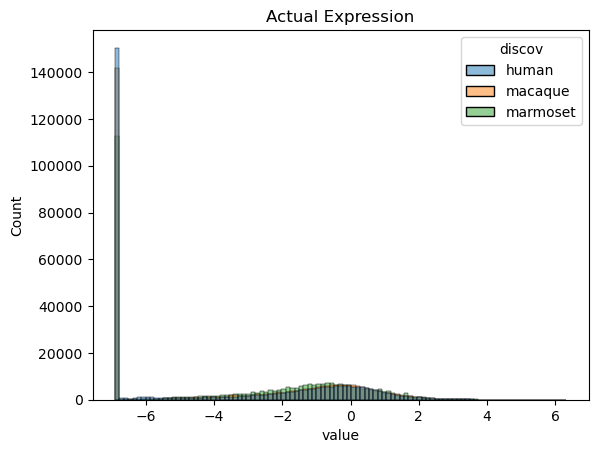

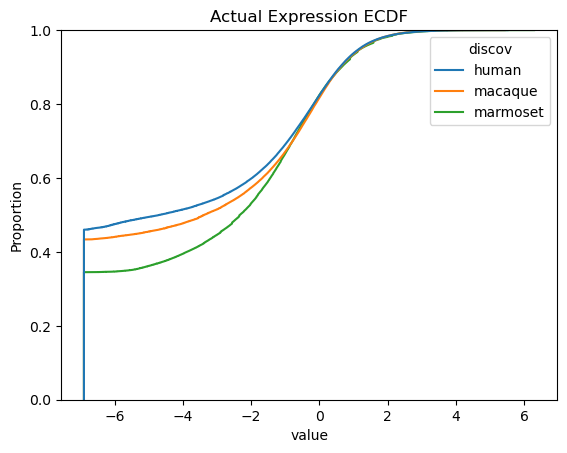

In [33]:
melted_means=melt_param_3d(log_real_means,discov_labels,cluster_labels,var_labels)
seaborn.histplot(data=melted_means,x='value',hue='discov')
plt.title('Actual Expression')
plt.show()
seaborn.ecdfplot(data=melted_means,x='value',hue='discov')
plt.title('Actual Expression ECDF')
plt.show()

In [37]:
adata.X.max()

51197

In [38]:
subclass_meangenes=pd.read_csv('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/data/mouse_wb/AIT21.all.freeze.230815_subclassmeans.csv',index_col=0)

 12%|█▏        | 12499/100000 [27:17<3:11:01,  7.63it/s]


In [ ]:
seaborn.ecdfplot(subclass_meangenes.to_numpy().flatten())
plt.title('Actual Expression ECDF')
plt.show()